### 법학 분류

In [ ]:
import pandas as pd

def debug_prompt_text(input_file):
    # 데이터 로드
    df = pd.read_csv(input_file)
    # 중복 제거 (실제 파이프라인과 동일하게)
    unique_papers = df.drop_duplicates(subset=['논문ID']).head(3)
    
    print("="*30)
    print("🚀 [DEBUG] API 전송 예정 텍스트 샘플")
    print("="*30)
    
    for i, (_, row) in enumerate(unique_papers.iterrows()):
        # 실제 classify_batch 함수에서 만드는 것과 동일한 로직
        items_text = f"- 제목: {row['제목']} / 키워드: {row['키워드']}\n"
        
        print(f"[{i+1}번 논문 전송 텍스트]:")
        print(items_text)
        print("-" * 30)

# 실행 (상세데이터 파일명을 넣으세요)
debug_prompt_text('법학_AI_논문_상세정보_리스트.csv')

### LLM으로 분류

In [ ]:
import pandas as pd
import google.generativeai as genai
from pydantic import BaseModel
from typing import List
from tqdm import tqdm
from enum import Enum
import time
import os
import json
from dotenv import load_dotenv
from typing import List, Literal

import pandas as pd
from google import genai  # ⭐ 변경!
from google.genai import types  # ⭐ 추가
from pydantic import BaseModel
from typing import List, Literal
from tqdm import tqdm
import time
import os
import json
from dotenv import load_dotenv

# 0. 설정 로드
load_dotenv()
API_KEY = os.getenv("GOOGLE_API_KEY")

print(f"현재 작업 경로: {os.getcwd()}")
print(f"✅ API 키 로드: {API_KEY[:4]}..." if API_KEY else "❌ API 키 없음")

# 1. Pydantic 모델 (동일)
class ClassificationItem(BaseModel):
    source_id: str
    category: Literal["형사법", "공법", "민사법", "기타"]

class BatchClassificationResponse(BaseModel):
    results: List[ClassificationItem]

# 2. 새 SDK로 API 설정
client = genai.Client(api_key=API_KEY)

# API 연결 테스트
try:
    print("🔌 API 연결 테스트 중...")
    test_response = client.models.generate_content(
        model='gemini-2.5-flash',  # 모델명 확인
        contents='테스트'
    )
    print(f"✅ API 연결 성공! 응답: {test_response.text[:30]}")
except Exception as e:
    print(f"❌ API 연결 실패: {e}")
    exit(1)

def classify_batch(batch_df):
    """20개의 논문을 하나의 프롬프트로 묶어 분류 요청"""
    items_text = ""
    for _, row in batch_df.iterrows():
        raw_keywords = str(row['키워드'])
        clean_keywords = raw_keywords.replace(']]>', '').strip()
        items_text += f"[ID: {row['source_id']}] 제목: {row['제목']} / 키워드: {clean_keywords}\n"
    
    print(f"📏 프롬프트 길이: {len(items_text)} 글자")
    
    prompt = f"""
    <역할>
    30년 이상의 경력을 지닌 대한민국의 법학가로서, 너는 법률 논문을 분류하는 작업을 진행해야 해.
    주어진 논문들의 제목과 키워드를 읽고 각 논문을 <분류 기준>을 따라 4개 카테고리 중 하나로 분류해줘.
    </역할>

    <분류 기준>
    1. 형사법: 형벌에 관한 사항을 규율하는 법 체계

    2. 공법: 국가, 지방자치단체 등 공적 기관 상호 간, 또는 국가·지방자치단체와 개인(사인) 사이의 관계를 규율하는 법 체계 중 형사법이 아닌 것 

    3. 민사법: 개인(사인) 간의 재산적·신분적 생활 관계를 규율하는 법 체계

    4. 기타: 위 세가지 분류 중 어느 하나에 명확하게 속하지 않거나 동시에 여러 분류에 속하는 법 체계
    </분류 기준>

    [대상 리스트]
    {items_text}
    
    각 논문에 대해 source_id와 category를 JSON 형식으로 반환해.
    """

    try:
        print(f"🔄 API 호출 시작... (배치 크기: {len(batch_df)})")
        start_time = time.time()
        
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=BatchClassificationResponse,
                temperature=0.0
            )
        )
        
        elapsed = time.time() - start_time
        print(f"✅ API 응답 완료 ({elapsed:.2f}초)")
        
        return response.text
        
    except Exception as e:
        print(f"❌ API 에러: {type(e).__name__} - {str(e)}")
        time.sleep(10)
        return None


def run_classification_pipeline(input_file, output_file):
    print(f"📋 {input_file} 로드 중...")
    df = pd.read_csv(input_file)
    
    if '논문ID' in df.columns:
        df = df.rename(columns={'논문ID': 'source_id'})
    
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()

    print(f"✅ 총 {len(unique_papers)}건의 논문을 분류합니다.")
    print(f"📦 배치 크기: 20개씩, 총 {(len(unique_papers) + 19) // 20}개 배치")
    # 메인 실행 전에 추가
    print("🧪 첫 배치 테스트...")
    test_batch = unique_papers.head(5)  # 5개만 테스트
    test_result = classify_batch(test_batch)
    print(f"테스트 결과: {test_result[:200] if test_result else 'None'}")

    batch_size = 20
    success_count = 0
    fail_count = 0
    
    for i in tqdm(range(0, len(unique_papers), batch_size), desc="LLM 분류 진행 중"):
        batch_df = unique_papers.iloc[i : i + batch_size]
        print(f"\n--- 배치 {i//batch_size + 1} 시작 (논문 {i+1}~{min(i+batch_size, len(unique_papers))}) ---")
        
        json_response = classify_batch(batch_df)
        
        if json_response:
            try:
                parsed_data = json.loads(json_response)
                batch_results = pd.DataFrame(parsed_data['results'])
                
                batch_merged = batch_results.merge(
                    batch_df[['source_id', '제목', '발행연도', '키워드']],
                    on='source_id'
                )
                
                header = not os.path.exists(output_file)
                batch_merged.to_csv(output_file, index=False, mode='a', 
                                   header=header, encoding='utf-8-sig')
                
                success_count += len(batch_df)
                print(f"✅ 저장 완료 ({len(batch_df)}건)")
                
            except Exception as e:
                fail_count += len(batch_df)
                print(f"❌ 파싱 에러: {e}")
        else:
            fail_count += len(batch_df)
            print(f"⚠️ 이 배치는 건너뜁니다.")
        
        time.sleep(1)
    
    print(f"\n{'='*60}")
    print(f"🎯 처리 완료: 성공 {success_count}건 / 실패 {fail_count}건")
    print(f"{'='*60}")
    
    if os.path.exists(output_file):
        final_df = pd.read_csv(output_file)
        print(f"\n🏁 최종 결과 저장: {output_file}")
        print(final_df['category'].value_counts())

if __name__ == "__main__":

    run_classification_pipeline(
        input_file='법학_AI_논문_상세정보_리스트.csv', 
        output_file='AI_논문_분야별_분류_최종(예시x).csv'
    )

### BERT Topic으로 분류

In [4]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import os

def perform_kobert_topic_modeling(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    
    # 텍스트 결합 (NaN 처리 및 공백 제거)
    df['combined_text'] = (
        df['제목'].fillna('') + " " + 
        df['초록'].fillna('') + " " + 
        df['키워드'].fillna('')
    ).str.strip()
    
    # 유효한 텍스트가 있는 행만 추출
    df = df[df['combined_text'] != ""].reset_index(drop=True)
    docs = df['combined_text'].tolist()

    # 2. Embedding 모델 로드 (jhgan/ko-sbert-sts)
    model_name = 'jhgan/ko-sbert-sts' 
    print(f"📡 모델 로딩 중: {model_name}...")
    
    embedding_model = SentenceTransformer(model_name)
    embedding_model.max_seq_length = 512 

    # 3. 벡터라이저 설정 (불용어 필터링)
    vectorizer_model = CountVectorizer(
        ngram_range=(1, 2), 
        stop_words=['인공지능', '분석', '연구', '고찰', '대한', '있으며', '따라']
    )

    # 4. BERTopic 모델 생성 (4개 클러스터)
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=4, 
        verbose=True
    )

    # 5. 모델 학습 및 결과 할당
    print("🚀 BERTopic 학습 시작...")
    topics, probs = topic_model.fit_transform(docs)
    df['Cluster_ID'] = topics

    # 6. 결과 저장 (combined_text 칼럼 제거)
    topic_info = topic_model.get_topic_info()
    
    # --- 수정된 부분: 저장용 데이터프레임에서 불필요한 칼럼 제거 ---
    df_output = df.drop(columns=['combined_text'])
    
    df_output.to_csv('법학_AI_논문_BERTopic_클러스터링.csv', index=False, encoding='utf-8-sig')
    topic_info.to_csv('클러스터별_대표키워드_정보.csv', index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print("✅ 분석 완료! 'combined_text'를 제외한 결과가 저장되었습니다.")
    return df_output, topic_info, topic_model

if __name__ == "__main__":
    file_name = '법학_AI_논문_상세정보_리스트.csv'
    if os.path.exists(file_name):
        result_df, info, model = perform_kobert_topic_modeling(file_name)
    else:
        print(f"❌ 파일을 찾을 수 없습니다: {file_name}")
        
# 실행 전 커널을 한 번 Restart 하시는 것을 권장합니다!
result_df, info, model = perform_kobert_topic_modeling('법학_AI_논문_상세정보_리스트.csv')

📡 모델 로딩 중: jhgan/ko-sbert-sts...


2026-02-09 20:22:48,827 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 BERTopic 학습 시작...


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

2026-02-09 20:23:02,278 - BERTopic - Embedding - Completed ✓
2026-02-09 20:23:02,278 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-09 20:23:04,990 - BERTopic - Dimensionality - Completed ✓
2026-02-09 20:23:04,991 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-09 20:23:05,026 - BERTopic - Cluster - Completed ✓
2026-02-09 20:23:05,027 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-09 20:23:06,740 - BERTopic - Representation - Completed ✓
2026-02-09 20:23:06,744 - BERTopic - Topic reduction - Reducing number of topics
2026-02-09 20:23:06,748 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-09 20:23:08,475 - BERTopic - Representation - Completed ✓
2026-02-09 20:23:08,480 - BERTopic - Topic reduction - Reduced number of topics from 27 to 4


...

2026-02-09 20:23:11,853 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 BERTopic 학습 시작...


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

2026-02-09 20:23:24,977 - BERTopic - Embedding - Completed ✓
2026-02-09 20:23:24,977 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-09 20:23:27,573 - BERTopic - Dimensionality - Completed ✓
2026-02-09 20:23:27,574 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-09 20:23:27,609 - BERTopic - Cluster - Completed ✓
2026-02-09 20:23:27,610 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-09 20:23:29,326 - BERTopic - Representation - Completed ✓
2026-02-09 20:23:29,330 - BERTopic - Topic reduction - Reducing number of topics
2026-02-09 20:23:29,334 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-09 20:23:31,054 - BERTopic - Representation - Completed ✓
2026-02-09 20:23:31,058 - BERTopic - Topic reduction - Reduced number of topics from 29 to 4


--------------------------------------------------
✅ 분석 완료! 'combined_text'를 제외한 결과가 저장되었습니다.


In [5]:
# 1. Cluster_ID별 빈도수 계산
cluster_counts = result_df['Cluster_ID'].value_counts().sort_index()

# 2. 비율(%) 계산
cluster_percentages = (cluster_counts / len(result_df)) * 100

# 3. 데이터프레임으로 깔끔하게 정리
summary_df = pd.DataFrame({
    '개수(건)': cluster_counts,
    '비율(%)': cluster_percentages.round(2)
})

# 인덱스 이름 설정 (Cluster_ID)
summary_df.index.name = 'Cluster ID'

print("=== 클러스터별 분포 요약 ===")
print(summary_df)

# (선택 사항) 요약 결과도 CSV로 저장하고 싶다면:
# summary_df.to_csv('클러스터_비율_통계.csv', encoding='utf-8-sig')

=== 클러스터별 분포 요약 ===
            개수(건)  비율(%)
Cluster ID              
-1            587  30.85
 0           1170  61.48
 1            135   7.09
 2             11   0.58


### 스펙트럴 클러스터링(전부 다)

In [6]:
import pandas as pd
import networkx as nx
import numpy as np
from sklearn.cluster import SpectralClustering
import os

def calculate_fixed_k_communities(node_file, edge_file, k=4, output_file='KCI_AI_노드_커뮤니티_4개고정.csv'):
    print(f"1/3. 데이터 로드 및 그래프 행렬 변환 중 (K={k})...")
    df_nodes = pd.read_csv(node_file)
    df_edges = pd.read_csv(edge_file)

    # 그래프 생성 (무방향)
    G = nx.Graph()
    G.add_nodes_from(df_nodes['node_id'])
    edges = list(zip(df_edges['source_id'], df_edges['target_id_final']))
    G.add_edges_from(edges)

    # 노드 순서 보존을 위한 리스트
    node_list = list(G.nodes())
    
    # 2/3. 스펙트럴 클러스터링 실행
    # 인접 행렬(Adjacency Matrix)을 기반으로 수학적 군집화 수행
    print(f"2/3. 스펙트럴 클러스터링 알고리즘 계산 중... (시간이 다소 소요될 수 있습니다)")
    adj_matrix = nx.to_numpy_array(G, nodelist=node_list)
    
    # n_clusters=4로 고정
    sc = SpectralClustering(
        n_clusters=k, 
        affinity='precomputed', 
        assign_labels='discretize', 
        random_state=42
    )
    labels = sc.fit_predict(adj_matrix)

    # 결과를 데이터프레임으로 변환
    df_partition = pd.DataFrame({'node_id': node_list, 'Community_ID': labels})

    print("3/3. 노드 메타데이터와 병합 및 저장 중...")
    # 기존 노드 정보와 병합
    df_final = df_nodes.merge(df_partition, on='node_id', how='left')
    
    # 커뮤니티별 분포 확인
    print("\n📊 지정된 4개 커뮤니티별 노드 수:")
    print(df_final['Community_ID'].value_counts().sort_index())

    # 결과 저장
    df_final.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\n✅ 분석 완료! 결과 저장: {output_file}")

    return df_final

if __name__ == "__main__":
    calculate_fixed_k_communities('KCI_AI_전용_논문_노드.csv', 'KCI_AI_전용_인용_엣지.csv', k=4)

1/3. 데이터 로드 및 그래프 행렬 변환 중 (K=4)...
2/3. 스펙트럴 클러스터링 알고리즘 계산 중... (시간이 다소 소요될 수 있습니다)
3/3. 노드 메타데이터와 병합 및 저장 중...

📊 지정된 4개 커뮤니티별 노드 수:
Community_ID
0    4859
1     118
2     171
3     471
Name: count, dtype: int64

✅ 분석 완료! 결과 저장: KCI_AI_노드_커뮤니티_4개고정.csv


## 스펙트럴 클러스터링 (only법학만)

In [3]:
import pandas as pd
import networkx as nx
import numpy as np
from sklearn.cluster import SpectralClustering
import os

def calculate_fixed_k_communities(filter_file, node_file, edge_file, k=4, output_file='KCI_AI_노드_커뮤니티_4개고정.csv'):
    print(f"0/3. 필터링 데이터 로드 중...")
    # 필터링 기준이 되는 논문 ID 리스트 로드
    df_filter = pd.read_csv(filter_file)
    valid_ids = set(df_filter['논문ID'].unique())
    print(f"   - 필터링 기준 논문 수: {len(valid_ids)}개")

    print(f"1/3. 데이터 로드 및 필터링 수행 중 (K={k})...")
    df_nodes = pd.read_csv(node_file)
    df_edges = pd.read_csv(edge_file)

    # 노드 필터링: node_id가 valid_ids에 속하는 경우만 유지
    df_nodes_filtered = df_nodes[df_nodes['node_id'].isin(valid_ids)].copy()
    filtered_node_ids = set(df_nodes_filtered['node_id'])
    
    # 엣지 필터링: source_id와 target_id_final 모두 valid_ids에 속하는 경우만 유지
    # (그래프의 무결성을 위해 양쪽 노드가 모두 존재해야 합니다)
    df_edges_filtered = df_edges[
        df_edges['source_id'].isin(filtered_node_ids) & 
        df_edges['target_id_final'].isin(filtered_node_ids)
    ].copy()

    print(f"   - 필터링 후 노드 수: {len(df_nodes_filtered)}개")
    print(f"   - 필터링 후 엣지 수: {len(df_edges_filtered)}개")

    # 그래프 생성 (무방향)
    G = nx.Graph()
    G.add_nodes_from(df_nodes_filtered['node_id'])
    edges = list(zip(df_edges_filtered['source_id'], df_edges_filtered['target_id_final']))
    G.add_edges_from(edges)

    # 노드 순서 보존을 위한 리스트
    node_list = list(G.nodes())
    
    # 2/3. 스펙트럴 클러스터링 실행
    if len(node_list) < k:
        print(f"⚠️ 경고: 필터링된 노드 수({len(node_list)})가 설정된 클러스터 수({k})보다 작습니다.")
        return None

    print(f"2/3. 스펙트럴 클러스터링 알고리즘 계산 중... (노드 {len(node_list)}개 대상)")
    adj_matrix = nx.to_numpy_array(G, nodelist=node_list)
    
    # n_clusters=k로 고정
    sc = SpectralClustering(
        n_clusters=k, 
        affinity='precomputed', 
        assign_labels='discretize', 
        random_state=42
    )
    labels = sc.fit_predict(adj_matrix)

    # 결과를 데이터프레임으로 변환
    df_partition = pd.DataFrame({'node_id': node_list, 'Community_ID': labels})

    print("3/3. 노드 메타데이터와 병합 및 저장 중...")
    # 필터링된 노드 정보와 병합 (원본 df_nodes가 아닌 df_nodes_filtered 사용)
    df_final = df_nodes_filtered.merge(df_partition, on='node_id', how='left')
    
    # 커뮤니티별 분포 확인
    print("\n📊 지정된 4개 커뮤니티별 노드 수:")
    print(df_final['Community_ID'].value_counts().sort_index())

    # 결과 저장
    df_final.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\n✅ 분석 완료! 결과 저장: {output_file}")

    return df_final

if __name__ == "__main__":
    # 파일 경로 설정
    filter_csv = '법학_AI_논문_상세정보_리스트.csv'
    node_csv = 'KCI_AI_전용_논문_노드.csv'
    edge_csv = 'KCI_AI_전용_인용_엣지.csv'
    
    if os.path.exists(filter_csv) and os.path.exists(node_csv) and os.path.exists(edge_csv):
        calculate_fixed_k_communities(filter_csv, node_csv, edge_csv, k=4)
    else:
        print("파일이 존재하지 않습니다. 경로를 확인해주세요.")

0/3. 필터링 데이터 로드 중...
   - 필터링 기준 논문 수: 1903개
1/3. 데이터 로드 및 필터링 수행 중 (K=4)...
   - 필터링 후 노드 수: 1903개
   - 필터링 후 엣지 수: 4977개
2/3. 스펙트럴 클러스터링 알고리즘 계산 중... (노드 1903개 대상)
3/3. 노드 메타데이터와 병합 및 저장 중...

📊 지정된 4개 커뮤니티별 노드 수:
Community_ID
0    1276
1     287
2      52
3     288
Name: count, dtype: int64

✅ 분석 완료! 결과 저장: KCI_AI_노드_커뮤니티_4개고정.csv


✅ 점유율 계산 완료! '분야별_점유율_추이(예시x).csv' 파일이 생성되었습니다.


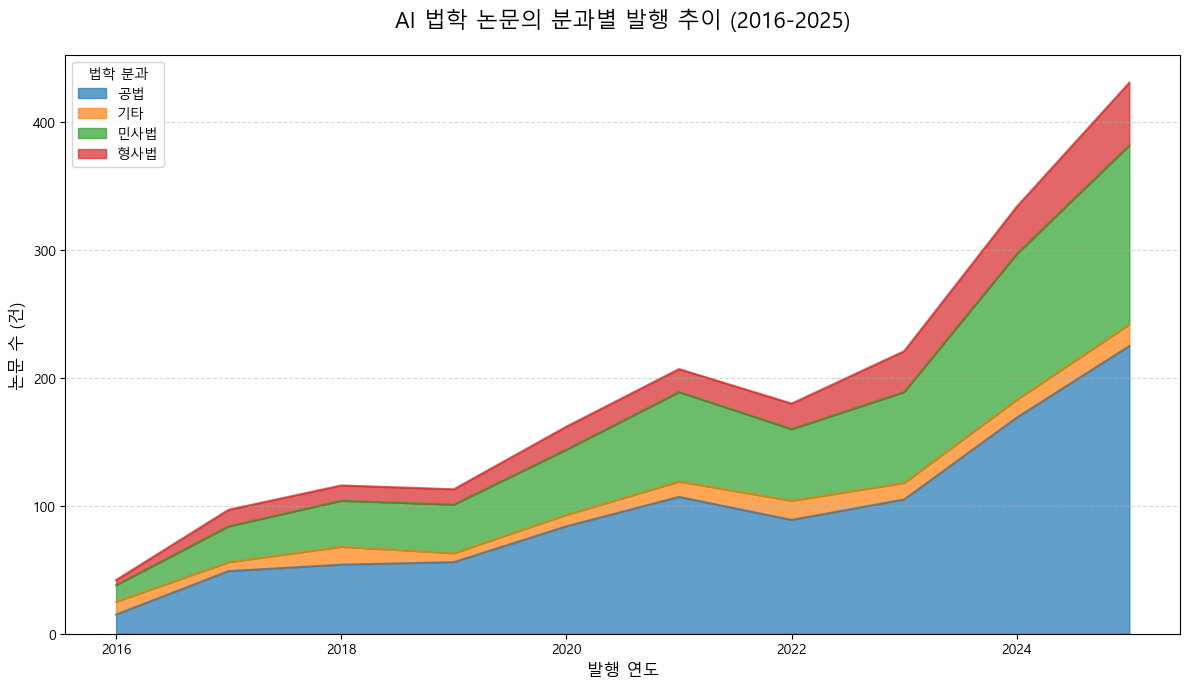

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_yearly_trends_with_share(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 2. 연도별/분류별 논문 '건수' 집계
    count_df = df.groupby(['발행연도', 'category']).size().unstack(fill_value=0)
    
    # 3. 점유율(%) 계산
    # 각 연도별 합계로 나누어 백분율을 구합니다.
    # 계산식: (해당 분야 건수 / 해당 연도 전체 건수) * 100
    share_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
    
    # 4. CSV 파일 저장
    # '분야별_점유율_추이.csv'로 저장합니다.
    share_df.to_csv('분야별_점유율_추이.csv', encoding='utf-8-sig')
    print(f"✅ 점유율 계산 완료! '분야별_점유율_추이(예시x).csv' 파일이 생성되었습니다.")
    
    # 5. 시각화 (기존 로직 유지)
    plt.figure(figsize=(12, 7))
    count_df.plot(kind='area', stacked=True, alpha=0.7, ax=plt.gca())
    
    plt.title('AI 법학 논문의 분과별 발행 추이 (2016-2025)', fontsize=16, pad=20)
    plt.xlabel('발행 연도', fontsize=12)
    plt.ylabel('논문 수 (건)', fontsize=12)
    plt.legend(title='법학 분과', loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('분야별_발행추이.png', dpi=300)
    plt.show()


plot_yearly_trends_with_share('AI_논문_분야별_분류_최종(예시x).csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_category_distribution(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 2. 통계 계산 (건수 및 비중)
    counts = df['분류'].value_counts()
    percentages = df['분류'].value_counts(normalize=True) * 100
    
    # 3. 데이터프레임 생성 및 CSV 저장
    dist_df = pd.DataFrame({
        '건수': counts,
        '비중(%)': percentages.round(2)
    })
    
    # 인덱스 이름(분류)을 명시적으로 지정하여 저장
    dist_df.index.name = '법학_분과'
    dist_df.to_csv('전체_분야별_점유율_합계.csv', encoding='utf-8-sig')
    print(f"✅ 전체 점유율 통계 완료! '전체_분야별_점유율_합계.csv'가 생성되었습니다.")
    
    # 4. 시각화 (도넛 차트 형태)
    plt.figure(figsize=(8, 8))
    colors = sns.color_palette('pastel')[0:4]
    
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=colors, wedgeprops={'edgecolor': 'white', 'width': 0.6})
    
    plt.title('전체 AI 법학 담론 내 분과별 점유율 (2016-2024)', fontsize=15, pad=20)
    plt.tight_layout()
    plt.savefig('분야별_점유율.png', dpi=300)
    plt.show()

plot_category_distribution('AI_논문_분야별_분류_최종.csv')

### 키워드

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_total_aggregated_keywords(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (필수)
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 불용어 리스트 강화 (법학 논문 일반 용어 제거)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 전체 기간 키워드 통합 및 빈도 계산
    all_keywords = unique_papers['cleaned_keywords'].sum()
    # 상위 30개 추출
    total_top_30 = Counter(all_keywords).most_common(30)

    # 3. CSV 파일 저장
    result_df = pd.DataFrame(total_top_30, columns=['키워드', '누적빈도'])
    result_df.to_csv('AI_법학_전체기간_누적_핵심키워드.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! 'AI_법학_전체기간_누적_핵심키워드.csv'가 저장되었습니다.")

    # 4. 시각화 (상위 30개 가로 바 차트)
    plt.figure(figsize=(12, 10))
    sns.barplot(x='누적빈도', y='키워드', data=result_df, palette='viridis')
    
    plt.title('대한민국 인공지능 법학 핵심 키워드 TOP 30 (2016-2025 통합)', fontsize=18, pad=20)
    plt.xlabel('누적 등장 빈도 (건)', fontsize=12)
    plt.ylabel('핵심 키워드', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('전체기간_누적_키워드_분석_30.png', dpi=300)
    plt.show()

# 실행
analyze_total_aggregated_keywords('AI_논문_분야별_분류_최종.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_yearly_keyword_transition(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (데이터 신뢰도 확보)
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        # ']]>' 제거 및 쉼표 분리
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 법학 논문 특유의 일반 단어 및 불용어 제외
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 연도별 Top 10 추출 및 CSV용 데이터 구성
    years = sorted(unique_papers['발행연도'].unique())
    num_years = len(years)
    
    yearly_results = []
    
    for year in years:
        # 해당 연도의 모든 논문 키워드 통합 (분류 무시)
        year_kws = unique_papers[unique_papers['발행연도'] == year]['cleaned_keywords'].sum()
        top_10 = Counter(year_kws).most_common(10)
        
        for rank, (word, freq) in enumerate(top_10, 1):
            yearly_results.append({
                '연도': int(year),
                '순위': rank,
                '키워드': word,
                '빈도': freq
            })

    # CSV 파일 저장
    result_df = pd.DataFrame(yearly_results)
    result_df.to_csv('연도별_전체_핵심키워드_변천사.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! '연도별_전체_핵심키워드_변천사.csv'가 저장되었습니다.")

    # 3. 시각화 (연도별 Top 10 바 차트 그리드)
    cols = 3
    rows = math.ceil(num_years / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        year_data = result_df[result_df['연도'] == year]
        
        if not year_data.empty:
            sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='viridis')
            axes[i].set_title(f'{year}년 주요 키워드 Top 10', fontsize=15, fontweight='bold')
            axes[i].set_xlabel('빈도')
            axes[i].set_ylabel('')

    # 빈 칸 제거
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('대한민국 인공지능 법학 키워드 변천 (2016-2025)', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.savefig('연도별_전체_키워드_변천사.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
analyze_yearly_keyword_transition('AI_논문_분야별_분류_최종.csv')

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_and_save_top_keywords(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 카테고리 순서 명시적으로 지정
    categories = ['공법', '민사법', '형사법', '기타']
    
    # 데이터를 저장할 리스트 초기화
    csv_data = []
    
    # 시각화 설정 (2x2 서브플롯)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    plt.rc('font', family='Malgun Gothic') 
    
    # 제외할 단어 리스트 (비교를 위해 모두 소문자로 작성)
    exclude_terms = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']

    for i, cat in enumerate(categories):
        # 해당 카테고리의 키워드 추출 및 세척
        cat_keywords = df[df['분류'] == cat]['키워드'].dropna()
        
        # 빈 리스트로 초기화
        raw_keywords = []
        for keyword_str in cat_keywords:
            raw_keywords.extend(str(keyword_str).split(','))
        
        clean_keywords = []
        for kw in raw_keywords:
            # [수정] ']]>' 제거, 공백 제거 후 모두 소문자로 변환
            cleaned = kw.replace(']]>', '').strip().lower()
            
            # 의미 없는 단어 및 빈 문자열 제외 (소문자로 변환된 단어와 비교)
            if cleaned and cleaned not in exclude_terms:
                clean_keywords.append(cleaned)
        
        # 2. 빈도 계산 (CSV용으로 상위 50개 추출)
        keyword_counts = Counter(clean_keywords).most_common(50)
        
        # CSV 저장을 위한 리스트 추가
        for word, count in keyword_counts:
            csv_data.append({
                '분류': cat,
                '키워드': word,
                '빈도': count
            })
        
        # 3. 시각화 (차트용으로 상위 10개만 사용)
        if keyword_counts:
            top_10 = keyword_counts[:10]
            words = [x[0] for x in top_10]
            counts = [x[1] for x in top_10]
            
            sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
            axes[i].set_title(f'[{cat}] 주요 키워드 TOP 10', fontsize=13)
            axes[i].set_xlabel('빈도')
            axes[i].set_ylabel('')

    # 4. CSV 파일 저장
    result_df = pd.DataFrame(csv_data)
    result_df.to_csv('분야별_핵심키워드_빈도_데이터.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분야별 키워드 빈도 분석 완료! '분야별_핵심키워드_빈도_데이터.csv'가 생성되었습니다.")

    plt.suptitle('법학 분야별 핵심 키워드', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('분야별_핵심키워드_세척완료.png', dpi=300)
    plt.show()

# 실행
plot_and_save_top_keywords('AI_논문_분야별_분류_최종.csv')

In [ ]:
import pandas as pd
import os

def analyze_and_save_keyword_metrics(input_file, output_file='AI_법학_키워드_동태지표.csv'):
    # 1. 데이터 로드
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    
    # [핵심] source_id 기반 중복 제거
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    print(f"📊 중복 제거 전 데이터: {len(df)}건")
    print(f"✅ 중복 제거 후 고유 논문: {len(unique_papers)}건")

    # 2. 키워드 세척 함수 (소문자 통합 로직 추가)
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        
        # ']]>' 제거 및 쉼표 분리
        raw_words = str(kw_str).replace(']]>', '').split(',')
        
        # [수정] 앞뒤 공백 제거 및 모두 소문자로 변환 (Case Normalization)
        cleaned = [w.strip().lower() for w in raw_words if w.strip()]
        
        # [수정] 불용어 리스트도 소문자로 구성하여 정확히 매칭되도록 함
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 3. 연도별 지표 계산
    years = sorted(unique_papers['발행연도'].unique())
    seen_keywords = set() # 누적 지식 저장소
    metrics_list = []

    for year in years:
        year_rows = unique_papers[unique_papers['발행연도'] == year]
        year_kws_all = year_rows['cleaned_keywords'].sum()
        
        # --- 지표 산출 ---
        tokens = len(year_kws_all)  # 전체 키워드 빈도 (소문자 통합 상태)
        types = len(set(year_kws_all))  # 고유 키워드 개수 (소문자 통합 상태)
        
        # TTR(Type-Token Ratio) 계산
        ttr = types / tokens if tokens > 0 else 0
        
        # 신규 키워드 산출 (과거에 등장하지 않았던 소문자 키워드 집합)
        current_year_unique = set(year_kws_all)
        new_kws = current_year_unique - seen_keywords
        new_kw_count = len(new_kws)
        
        # 결과 기록
        metrics_list.append({
            '연도': int(year),
            '고유논문수': len(year_rows),
            '전체키워드빈도(Tokens)': tokens,
            '고유키워드개수(Types)': types,
            '어휘다양성(TTR)': round(ttr, 4),
            '신규키워드수': new_kw_count
        })
        
        # 누적 저장소 업데이트
        seen_keywords.update(current_year_unique)

    # 4. CSV 저장
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print(f"🏁 분석 완료! 결과가 '{output_file}'에 저장되었습니다.")
    print(metrics_df.to_string(index=False))
    
    return metrics_df

# 실행
final_stats = analyze_and_save_keyword_metrics('AI_논문_분야별_분류_최종.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set font for Korean display
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_dual_axis_metrics(csv_file):
    df = pd.read_csv(csv_file)
    
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar chart for New Keywords (Left Y-axis)
    color_bar = '#D3D3D3'  # Light Gray
    bars = ax1.bar(df['연도'], df['신규키워드수'], color=color_bar, alpha=0.7, label='신규 등장 키워드 수')
    ax1.set_xlabel('연도', fontsize=12)
    ax1.set_ylabel('신규 키워드 수 (건)', fontsize=12)
    ax1.set_xticks(df['연도'])

    # Line chart for TTR (Right Y-axis)
    ax2 = ax1.twinx()
    color_line = '#1F77B4'  # Professional Blue
    line = ax2.plot(df['연도'], df['어휘다양성(TTR)'], color=color_line, marker='o', linewidth=2.5, markersize=8, label='어휘 다양성 (TTR)')
    ax2.set_ylabel('어휘 다양성 지수 (TTR)', fontsize=12, color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax2.set_ylim(0, 1.0) # TTR is a ratio between 0 and 1

    # Adding legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)

    plt.title('한국 인공지능 신규 키워드 추이', fontsize=16, pad=20)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('AI_법학_동태지표_혼합그래프.png', dpi=300)
    plt.show() # Not showing, just saving as per instructions

plot_dual_axis_metrics('AI_법학_키워드_동태지표.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set font for Korean display
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_new_keywords(csv_file):
    df = pd.read_csv(csv_file)
    
    fig, ax = plt.subplots(figsize=(12, 7))

    # Line chart for New Keywords
    color_line = '#1F77B4'  # Professional Blue
    ax.plot(df['연도'], df['신규키워드수'], color=color_line, marker='o', 
            linewidth=2.5, markersize=8, label='신규 등장 키워드 수')
    
    ax.set_xlabel('연도', fontsize=12)
    ax.set_ylabel('신규 키워드 수 (건)', fontsize=12)
    ax.set_xticks(df['연도'])
    
    # Adding legend
    ax.legend(loc='upper left', frameon=True)

    plt.title('한국 인공지능 신규 키워드 추이', fontsize=16, pad=20)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('AI_법학_동태지표_혼합그래프.png', dpi=300)
    plt.show()

plot_new_keywords('AI_법학_키워드_동태지표.csv')

### 분류별 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_by_category(input_file):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()

    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        raw_words = str(kw_str).replace(']]>', '').split(',')
        cleaned = [w.strip() for w in raw_words if w.strip()]
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분야별/연도별 지표 계산
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['발행연도'].unique())
    
    all_metrics = []
    
    # 분야별로 독립적인 '이미 등장한 키워드' 집합 관리
    category_seen_keywords = {cat: set() for cat in categories}

    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        
        for year in years:
            year_rows = cat_df[cat_df['발행연도'] == year]
            if len(year_rows) == 0:
                continue
                
            year_kws_all = year_rows['cleaned_keywords'].sum()
            
            # TTR 계산
            tokens = len(year_kws_all)
            types = len(set(year_kws_all))
            ttr = types / tokens if tokens > 0 else 0
            
            # 해당 분야 내 신규 키워드 산출
            current_year_unique = set(year_kws_all)
            new_kws = current_year_unique - category_seen_keywords[cat]
            new_kw_count = len(new_kws)
            
            # 지표 저장
            all_metrics.append({
                '분류': cat,
                '연도': int(year),
                'TTR': ttr,
                '신규키워드수': new_kw_count,
                '논문수': len(year_rows)
            })
            
            # 해당 분야의 누적 집합 업데이트
            category_seen_keywords[cat].update(current_year_unique)

    return pd.DataFrame(all_metrics)

def plot_category_metrics(metrics_df):
    # 시각화 설정: 1행 2열 (TTR 추이, 신규 키워드 추이)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. 분야별 어휘 다양성(TTR) 추이
    sns.lineplot(data=metrics_df, x='연도', y='TTR', hue='분류', marker='o', ax=ax1, linewidth=2)
    ax1.set_title('분과별 어휘 다양성(TTR) 추이', fontsize=15, pad=15)
    ax1.set_ylabel('TTR (전문성/수렴도)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. 분야별 신규 등장 키워드 수 추이
    sns.lineplot(data=metrics_df, x='연도', y='신규키워드수', hue='분류', marker='s', ax=ax2, linewidth=2)
    ax2.set_title('분류별 신규 등장 키워드 수 추이', fontsize=15, pad=15)
    ax2.set_ylabel('신규 키워드 수 (확장성)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('법학 분야별 AI 담론 동태 분석 (2016-2024)', fontsize=20, y=1.05)
    plt.tight_layout()
    plt.savefig('분과별_키워드_동태분석.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
metrics_by_cat = analyze_by_category('AI_논문_분야별_분류_최종.csv')
plot_category_metrics(metrics_by_cat)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_by_category(input_file):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()

    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        raw_words = str(kw_str).replace(']]>', '').split(',')
        cleaned = [w.strip() for w in raw_words if w.strip()]
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분야별/연도별 지표 계산
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['발행연도'].unique())
    
    all_metrics = []
    
    # 분야별로 독립적인 '이미 등장한 키워드' 집합 관리
    category_seen_keywords = {cat: set() for cat in categories}

    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        
        for year in years:
            year_rows = cat_df[cat_df['발행연도'] == year]
            if len(year_rows) == 0:
                continue
                
            year_kws_all = year_rows['cleaned_keywords'].sum()
            
            # TTR 계산
            tokens = len(year_kws_all)
            types = len(set(year_kws_all))
            ttr = types / tokens if tokens > 0 else 0
            
            # 해당 분야 내 신규 키워드 산출
            current_year_unique = set(year_kws_all)
            new_kws = current_year_unique - category_seen_keywords[cat]
            new_kw_count = len(new_kws)
            
            # 지표 저장
            all_metrics.append({
                '분류': cat,
                '연도': int(year),
                'TTR': ttr,
                '신규키워드수': new_kw_count,
                '논문수': len(year_rows)
            })
            
            # 해당 분야의 누적 집합 업데이트
            category_seen_keywords[cat].update(current_year_unique)

    return pd.DataFrame(all_metrics)

def plot_category_metrics(metrics_df):
    # 시각화 설정: 신규 키워드 추이만 표시
    fig, ax = plt.subplots(figsize=(14, 8))

    # 분야별 신규 등장 키워드 수 추이
    sns.lineplot(data=metrics_df, x='연도', y='신규키워드수', hue='분류', marker='o', ax=ax, linewidth=2.5)
    ax.set_title('법학 분야별 신규 등장 키워드 수 추이 (2016-2025)', fontsize=16, pad=20)
    ax.set_xlabel('연도', fontsize=13)
    ax.set_ylabel('신규 키워드 수 (건)', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title='분류', fontsize=11, title_fontsize=12)

    plt.tight_layout()
    plt.savefig('분과별_키워드_동태분석.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
metrics_by_cat = analyze_by_category('AI_논문_분야별_분류_최종.csv')
plot_category_metrics(metrics_by_cat)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_top_keywords_by_category(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 대소문자 통합(lower) 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 분석 제외어 (사용자 요청 반영)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal', '연구', '분석']
        return [w for w in cleaned if w not in stopwords]
    
    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분류별/연도별 데이터 집계
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['발행연도'].unique())
    num_years = len(years)
    
    combined_results = []

    # 3. 카테고리별 반복 처리
    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        print(f"📊 [{cat}] 분과 분석 중...")
        
        # 시각화 설정 (카테고리당 하나의 이미지 생성)
        cols = 3
        rows = math.ceil(num_years / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
        axes = axes.flatten()
        
        for i, year in enumerate(years):
            year_kws = cat_df[cat_df['발행연도'] == year]['cleaned_keywords'].sum()
            
            # 키워드가 없는 연도 대응
            if not year_kws:
                axes[i].axis('off')
                continue
                
            top_5 = Counter(year_kws).most_common(5)
            
            # 데이터 저장용 리스트에 추가
            for rank, (word, freq) in enumerate(top_5, 1):
                combined_results.append({
                    '분류': cat,
                    '연도': int(year),
                    '순위': rank,
                    '키워드': word,
                    '빈도': freq
                })
            
            # 개별 차트 생성
            if top_5:
                words = [x[0] for x in top_5]
                counts = [x[1] for x in top_5]
                sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
                axes[i].set_title(f'📅 {year}년 ({cat})', fontsize=12, fontweight='bold')
                axes[i].set_xlabel('')
                axes[i].set_ylabel('')

        # 남는 칸 제거 및 저장
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.suptitle(f'[{cat}] 분과 연도별 주요 담론 변화', fontsize=20, y=1.02)
        plt.tight_layout()
        filename = f'분류별_키워드추이_{cat.replace("/", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close() # 메모리 관리를 위해 닫기

    # 4. 통합 CSV 저장
    result_df = pd.DataFrame(combined_results)
    result_df.to_csv('분류별_연도별_핵심_키워드_Top5.csv', index=False, encoding='utf-8-sig')
    print("-" * 50)
    print(f"✅ 분석 완료!")
    print(f"📁 CSV 저장: 분류별_연도별_핵심_키워드_Top5.csv")
    print(f"🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료")

# 실행
analyze_top_keywords_by_category('AI_논문_분야별_분류_최종.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_top_keywords_by_category(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    # 연도를 기간으로 매핑하는 함수
    def map_year_to_period(year):
        if 2016 <= year <= 2018:
            return '2016-2018'
        elif 2019 <= year <= 2021:
            return '2019-2021'
        elif 2022 <= year <= 2025:
            return '2022-2025'
        else:
            return None
    
    # 기간 컬럼 추가
    unique_papers['기간'] = unique_papers['발행연도'].apply(map_year_to_period)
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 대소문자 통합(lower) 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 분석 제외어 (사용자 요청 반영)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal', '연구', '분석']
        return [w for w in cleaned if w not in stopwords]
    
    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)
    
    # 2. 분류별/기간별 데이터 집계
    categories = ['공법', '민사법', '형사법', '기타']  # 순서 고정
    periods = ['2016-2018', '2019-2021', '2022-2025']
    num_periods = len(periods)
    
    combined_results = []
    
    # 3. 카테고리별 반복 처리
    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        print(f"📊 [{cat}] 분과 분석 중...")
        
        # 시각화 설정 (카테고리당 하나의 이미지 생성, 3개 기간)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, period in enumerate(periods):
            period_kws = cat_df[cat_df['기간'] == period]['cleaned_keywords'].sum()
            
            # 키워드가 없는 기간 대응
            if not period_kws:
                axes[i].axis('off')
                axes[i].text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
                continue
                
            top_10 = Counter(period_kws).most_common(10)
            
            # 데이터 저장용 리스트에 추가
            for rank, (word, freq) in enumerate(top_10, 1):
                combined_results.append({
                    '분류': cat,
                    '기간': period,
                    '순위': rank,
                    '키워드': word,
                    '빈도': freq
                })
            
            # 개별 차트 생성
            if top_10:
                words = [x[0] for x in top_10]
                counts = [x[1] for x in top_10]
                sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
                axes[i].set_title(f' {period}', fontsize=13, fontweight='bold')
                axes[i].set_xlabel('빈도')
                axes[i].set_ylabel('')
        
        plt.suptitle(f'[{cat}] 분과 기간별 주요 담론 변화 (Top 10)', fontsize=18, y=1.02)
        plt.tight_layout()
        filename = f'분류별_키워드추이_{cat.replace("/", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()  # 메모리 관리를 위해 닫기
    
    # 4. 통합 CSV 저장
    result_df = pd.DataFrame(combined_results)
    result_df.to_csv('분류별_기간별_핵심_키워드_Top10.csv', index=False, encoding='utf-8-sig')
    print("-" * 50)
    print(f"✅ 분석 완료!")
    print(f"📁 CSV 저장: 분류별_기간별_핵심_키워드_Top10.csv")
    print(f"🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료")

# 실행
analyze_top_keywords_by_category('AI_논문_분야별_분류_최종.csv')

### 연도 추세분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_growth_and_ratio(ai_file, total_file):
    # 1. 데이터 로드
    df_ai = pd.read_csv(ai_file)
    df_total = pd.read_csv(total_file)
    
    # 2. 연도별 집계 (2016-2025 범위 한정)
    # AI 논문 수 계산
    ai_counts = df_ai.groupby('발행연도').size().rename('AI_논문수')
    
    # 전체 법학 논문 수 계산 ('발행연도' 컬럼 기준)
    total_counts = df_total.groupby('발행연도').size().rename('전체_법학_논문수')
    
    # 두 데이터 합치기
    stats = pd.concat([total_counts, ai_counts], axis=1).fillna(0)
    stats = stats.loc[2016:2025] # 분석 기간 설정
    
    # 3. 지표 계산
    # (1) 전체 대비 비중 (%)
    stats['AI_비중(%)'] = (stats['AI_논문수'] / stats['전체_법학_논문수']) * 100
    
    # (2) 연평균 성장률(CAGR) 계산
    # 공식: (끝값 / 시작값) ^ (1 / 기간) - 1
    begin_val = stats['AI_논문수'].iloc[0]
    end_val = stats['AI_논문수'].iloc[-1]
    n_years = len(stats) - 1
    cagr = (end_val / begin_val)**(1 / n_years) - 1
    
    print(f"📈 2015-2024 AI 법학 연평균 성장률(CAGR): {cagr:.2%}")
    print(stats[['전체_법학_논문수', 'AI_논문수', 'AI_비중(%)']])

    # 4. 시각화 (이중 축 그래프)
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # 축 1: AI 논문 수 (막대 그래프)
    sns.barplot(x=stats.index, y=stats['AI_논문수'], ax=ax1, color='skyblue', alpha=0.7, label='AI 논문 수')
    ax1.set_ylabel('AI 법학 논문 수 (건)', fontsize=12)
    ax1.set_xlabel('연도', fontsize=12)
    
    # 축 2: 비중 (꺾은선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(x=np.arange(len(stats)), y=stats['AI_비중(%)'], ax=ax2, color='red', marker='o', linewidth=2, label='전체 법학 대비 비중 (%)')
    ax2.set_ylabel('전체 법학 대비 비중 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 타이틀 및 범례
    plt.title(f'연도별 인공지능 법학 논문 출간 수 및 전체 법학 논문 대비 비율 ', fontsize=16, pad=20)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('AI법학_성장성_및_비중분석.png', dpi=300)
    plt.show()

analyze_growth_and_ratio('AI_논문_분야별_분류_최종.csv', '전체_법학_논문목록_정제본.csv')

# 여기부터 네트워크 분석

전처리 및 가상ID 처리

In [3]:
import pandas as pd
from tqdm import tqdm

def run_kci_only_ai_preprocessing(node_file, edge_file):
    print("1/4. 데이터 로드 및 2016-2025 AI 시드(Seed) 논문 필터링...")
    df_nodes = pd.read_csv(node_file)
    
    # AI 키워드 패턴
    AI_PATTERN = r'\bAI\b|(?i:Artificial Intelligence)|인공지능'

    # [수정] 2016년~2025년 범위 설정 및 키워드 필터링
    mask_year = (df_nodes['발행연도'] >= 2016) & (df_nodes['발행연도'] <= 2025)
    mask_keyword = (
        df_nodes['제목'].str.contains(AI_PATTERN, case=True, na=False) | 
        df_nodes['초록'].str.contains(AI_PATTERN, case=True, na=False)
    )
    
    # 최종 AI 시드 논문 (2016~2025 사이에 발행된 AI 관련 법학 논문 전체)
    ai_seed_df = df_nodes[mask_year & mask_keyword].copy()
    ai_seed_ids = set(ai_seed_df['논문ID'].unique())
    all_kci_ids = set(df_nodes['논문ID'].unique()) 
    
    print(f"   -> 분석 대상 AI 시드 논문 선정: {len(ai_seed_ids)}편 (2016-2025)")

    print("2/4. 인용 엣지 필터링 (Source가 AI 시드 논문인 경우)...")
    df_edges = pd.read_csv(edge_file)
    
    # 필터링 규칙:
    # 1. 인용을 한 논문(source_id)이 우리가 정한 2016-2025 AI 시드 논문 리스트에 있어야 함
    # 2. 인용을 당한 논문(target_arti_id)이 전체 KCI 리스트에 존재해야 함
    mask_kci_to_kci = (
        df_edges['source_id'].isin(ai_seed_ids) & 
        df_edges['target_arti_id'].notna() & 
        df_edges['target_arti_id'].isin(all_kci_ids)
    )
    
    final_edges = df_edges[mask_kci_to_kci].copy()
    final_edges = final_edges.rename(columns={'target_arti_id': 'target_id_final'})
    
    print(f"   -> 추출된 인용 관계 수: {len(final_edges)}")

    print("3/4. 최종 분석 대상 노드 리스트 정리 (고립 노드 포함)...")
    # [수정 핵심]: 엣지에 있는 논문뿐만 아니라, 인용 관계가 없는 AI 시드 논문들도 모두 노드에 포함
    cited_node_ids = set(final_edges['target_id_final'].unique())
    final_node_ids = ai_seed_ids | cited_node_ids # 합집합 (AI 시드 전체 + 인용된 논문들)
    
    # 노드 메타데이터 추출
    final_nodes = df_nodes[df_nodes['논문ID'].isin(final_node_ids)].copy()
    final_nodes = final_nodes.rename(columns={'논문ID': 'node_id'})
    
    # [추가] 해당 논문이 AI 시드 논문인지 표시 (나중에 분석 시 편리함)
    final_nodes['is_ai_seed'] = final_nodes['node_id'].isin(ai_seed_ids)
    
    print("4/4. 데이터 저장 중...")
    final_edges[['source_id', 'target_id_final', 'ref_type']].to_csv('KCI_AI_전용_인용_엣지.csv', index=False, encoding='utf-8-sig')
    final_nodes[['node_id', '발행연도', '제목', '저자', '학술지명', 'is_ai_seed']].to_csv('KCI_AI_전용_논문_노드.csv', index=False, encoding='utf-8-sig')

    print(f"\n✅ 정제 완료 (범위: 2016-2025)!")
    print(f"- 결과 노드 수: {len(final_nodes)}개 (AI 시드 {len(ai_seed_ids)}개 + 피인용 논문 포함)")
    print(f"- 결과 엣지 수: {len(final_edges)}개")

if __name__ == "__main__":
    run_kci_only_ai_preprocessing('전체_법학_논문목록_정제본.csv', '법학_인용_네트워크_데이터_전체.csv')

1/4. 데이터 로드 및 2016-2025 AI 시드(Seed) 논문 필터링...


KeyboardInterrupt: 

In [ ]:
# 최종 정제된 노드 파일 로드
final_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')

# 발행연도별 분포 확인
year_dist = final_nodes['발행연도'].value_counts().sort_index()
print("📊 최종 데이터에 포함된 논문의 발행연도 분포:")
print(year_dist.head(10)) # 아주 오래된 논문들도 포함되어 있을 것입니다.

# 2015년 이전 논문 비중 계산
pre_2015 = final_nodes[final_nodes['발행연도'] < 2015]
print(f"\n💡 2015년 이전 발행된 논문 수: {len(pre_2015)}개")

# 분절분석

In [ ]:
import pandas as pd
import networkx as nx
from tqdm import tqdm

# 1. 데이터 로드
df_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
df_edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 2. 분석을 위해 엣지 데이터에 Source 논문의 발행연도 매칭
df_edges = df_edges.merge(df_nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def analyze_discrete_network(start_year=2016, end_year=2025):
    yearly_metrics = []
    
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 지표 계산 중"):
        # --- [추가 코드] 해당 연도에 실제로 '발행'된 논문 숫자 계산 ---
        num_papers_published = len(df_nodes[df_nodes['발행연도'] == year])
        
        # 해당 연도에 발행된 논문들이 생성한 엣지만 추출
        year_edges = df_edges[df_edges['발행연도'] == year]
        
        if year_edges.empty:
            # 엣지가 없더라도 발행 논문 수는 기록하기 위해 처리
            yearly_metrics.append({
                '연도': year,
                '발행논문수': num_papers_published,
                '네트워크_노드수': 0,
                '엣지수': 0,
                '밀도': 0,
                '주요논문': "데이터 없음"
            })
            continue
            
        # 그래프 생성
        G = nx.DiGraph()
        G.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
        
        # 지표 계산
        num_nodes = G.number_of_nodes() # 네트워크에 포함된 논문 수 (인용한 논문 + 인용된 논문)
        num_edges = G.number_of_edges()
        density = nx.density(G)
        
        # 인차수(In-degree) 상위 논문 추출
        in_degrees = dict(G.in_degree())
        top_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
        
        top_titles = []
        for node_id, count in top_nodes:
            title_info = df_nodes[df_nodes['node_id'] == node_id]['제목']
            title = title_info.values[0] if not title_info.empty else "Unknown"
            top_titles.append(f"{title}({count}회)")
            
        yearly_metrics.append({
            '연도': year,
            '발행논문수': num_papers_published,  # 추가된 지표
            '네트워크_노드수': num_nodes,
            '엣지수': num_edges,
            '밀도': round(density, 5),
            '주요논문': ", ".join(top_titles)
        })
        
    return pd.DataFrame(yearly_metrics)

# 분석 실행
discrete_results = analyze_discrete_network()
discrete_results.to_csv('연도별_분절분석_결과.csv', index=False, encoding='utf-8-sig')

print("\n📊 연도별 주요 지표 요약 (발행논문수 포함):")
print(discrete_results[['연도', '발행논문수', '네트워크_노드수', '엣지수', '밀도']])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 결과 데이터 로드
df = pd.read_csv('연도별_분절분석_결과.csv')

# 2. 시각화 (이중 축 활용)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 축 1: 발행논문수 및 네트워크 노드수 (Bar)
# 두 데이터를 나란히 보여주기 위해 바 차트를 겹치거나 나열할 수 있습니다.
ax1.bar(df['연도'] - 0.2, df['발행논문수'], width=0.4, color='lightgray', alpha=0.7, label='Published AI Papers')
ax1.bar(df['연도'] + 0.2, df['네트워크_노드수'], width=0.4, color='skyblue', alpha=0.6, label='Nodes in Network (Citing/Cited)')

# 축 1: 엣지수 (Line) - 인용 관계의 총량
ax1.plot(df['연도'], df['엣지수'], color='steelblue', marker='o', linewidth=2, label='Edges (Citations)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Count (Papers/Citations)', fontsize=12)
ax1.set_xticks(df['연도'])
ax1.legend(loc='upper left')

# 축 2: 밀도 (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.plot(df['연도'], df['밀도'], color='tab:red', marker='s', linestyle='--', label='Network Density')
ax2.set_ylabel('Network Density', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# 그래프 제목 및 설정
plt.title('Growth and Structural Evolution of AI Law Research (2015-2024)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('AI_law_discrete_trends_updated.png', dpi=300)
plt.show()

###

# 개별 분석 시작

## 발행연도 상관 없이 특정 연도까지 인용된 모든 논문

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '01_AI_누적_지식_기반_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
# 데이터 파일명은 사용자님의 파일 환경에 맞춰 'KCI_AI_전용_논문_노드.csv' 등으로 수정 가능합니다.
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (Source 논문의 발행연도를 기준으로 누적 범위를 결정)
# 주의: 이 merge는 인용을 '한' 논문의 연도를 붙이는 작업입니다.
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_cumulative_intellectual_base_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 누적 분석 진행 중"):
        # [핵심 로직] 기준 연도(year) 이하에 발행된 논문들이 생성한 모든 엣지 추출
        # 2015년 이전의 인용 기록이 edges에 있다면, 이 필터링을 통해 과거의 권위가 합산됩니다.
        cum_edges = edges_with_year[edges_with_year['발행연도'] <= year]
        
        if cum_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(cum_edges['source_id'], cum_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain은 비방향 그래프 기준)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            # 해당 커뮤니티 소속 노드 추출
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 커뮤니티 내 논문들을 피인용수(In-degree) 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '발행연도': paper_info['발행연도'].values[0],
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"cumulative_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_cumulative_intellectual_base_tracking()
    print(f"\n✅ 누적 지식 기반 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 발행연도 상관 없이 특정 연도에 인용된 모든 논문

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '02_AI_시점별_담론_지형_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (인용을 수행한 Source 논문의 발행연도 기준)
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_snapshot_discourse_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 스냅샷 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 발행된 논문들이 생성한 엣지만 추출
        # 이 필터링을 통해 '그해의 연구자들이 선택한 지식'만 남게 됩니다.
        snapshot_edges = edges_with_year[edges_with_year['발행연도'] == year]
        
        if snapshot_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(snapshot_edges['source_id'], snapshot_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 당해 연도 피인용수 기준으로 정렬 (해당 시점의 인기 논문 식별)
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수(당해)': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '원래_발행연도': paper_info['발행연도'].values[0],
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"snapshot_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_snapshot_discourse_tracking()
    print(f"\n 시점별 담론 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 특정 연도에 발행한 논문의 중 피인용 횟수 기준

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '03_AI_연도별_신성_담론_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

def run_rising_star_paper_tracking(start_year=2015, end_year=2024):
    print("전체 기간 통합 네트워크 분석 중 (지식 구조 식별)...")
    # [핵심 로직] 전체 기간의 엣지를 사용하여 '글로벌 위상'과 '글로벌 커뮤니티'를 먼저 계산합니다.
    G_total = nx.DiGraph()
    G_total.add_edges_from(zip(edges['source_id'], edges['target_id_final']))
    
    # 1. 전체 네트워크에서의 피인용수(Global In-degree) 계산
    global_in_degrees = dict(G_total.in_degree())
    
    # 2. 전체 네트워크에서의 커뮤니티 탐지 (지식의 거대한 줄기 파악)
    G_undir = G_total.to_undirected()
    global_partition = louvain.best_partition(G_undir)
    global_comm_counts = Counter(global_partition.values())

    for year in tqdm(range(start_year, end_year + 1), desc="연도별 발행작 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 '발행된' 논문들만 추출
        year_born_papers = nodes[nodes['발행연도'] == year].copy()
        
        if year_born_papers.empty:
            continue
            
        # 글로벌 지표 결합
        year_born_papers['인용수_전체'] = year_born_papers['node_id'].map(global_in_degrees).fillna(0)
        year_born_papers['커뮤니티_ID'] = year_born_papers['node_id'].map(global_partition)
        
        # 해당 연도 발행작들이 기여하고 있는 상위 5개 글로벌 커뮤니티 식별
        top_5_comms = year_born_papers['커뮤니티_ID'].value_counts().head(5).index
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_comms, 1):
            # 해당 연도 발행 + 특정 커뮤니티 소속 논문 필터링
            comm_papers = year_born_papers[year_born_papers['커뮤니티_ID'] == comm_id]
            
            # 전체 피인용수 기준으로 정렬 (미래의 고전이 될 논문 식별)
            top_5_papers = comm_papers.sort_values(by='인용수_전체', ascending=False).head(5)
            
            for paper_rank, (_, row) in enumerate(top_5_papers.iterrows(), 1):
                year_data.append({
                    '커뮤니티_순위': comm_rank,
                    '커뮤니티_ID': comm_id,
                    '커뮤니티_전체크기': global_comm_counts[comm_id],
                    '논문_순위': paper_rank,
                    '누적_인용수': row['인용수_전체'],
                    '제목': row['제목'],
                    '저자': row['저자'],
                    '발행연도': year, # 파일 내 확인용
                    'node_id': row['node_id']
                })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"rising_stars_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_rising_star_paper_tracking()
    print(f"\n 연도별 신성 담론 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 특정 연도에 발행한 논문의 중 피인용 횟수 기준 2년 이내

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '04_AI_최신_연구_전선_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 Source(인용한 논문)와 Target(인용된 논문)의 발행연도를 모두 매칭
# 1. Source 연도 매칭
edges_meta = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')
edges_meta = edges_meta.rename(columns={'발행연도': 'source_year'})

# 2. Target 연도 매칭
edges_meta = edges_meta.merge(nodes[['node_id', '발행연도']], left_on='target_id_final', right_on='node_id', how='left')
edges_meta = edges_meta.rename(columns={'발행연도': 'target_year'})

def run_research_front_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연구 전선 분석 진행 중"):
        # [핵심 로직] 
        # 1. 인용 대상(Target)이 분석 연도(year)에 발행된 논문이어야 함
        # 2. 인용한 논문(Source)이 발행 연도부터 +1년(year+1) 사이에 발행되어야 함
        mask_front = (edges_meta['target_year'] == year) & \
                     (edges_meta['source_year'] >= year) & \
                     (edges_meta['source_year'] <= year + 1)
        
        front_edges = edges_meta[mask_front]
        
        if front_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(front_edges['source_id'], front_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 단기 피인용수 기준으로 정렬 (초기 파급력이 강한 논문 식별)
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '단기_인용수(2년)': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '발행연도': year,
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"research_front_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_research_front_tracking()
    print(f"\n✅ 최신 연구 전선 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

### 엑셀 컴바인

In [ ]:
import pandas as pd
import os

# 1. CSV 파일들이 있는 폴더 경로 설정
folder_path = './03_AI_연도별_신성_담론_분석'  # CSV 파일이 저장된 폴더명으로 수정하세요
output_file = '03_AI_연도별_신성_담론_분석.xlsx'

# 2. ExcelWriter 객체 생성
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # 폴더 내의 모든 파일 확인
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            # 파일 경로 생성
            file_path = os.path.join(folder_path, file_name)
            
            # CSV 읽기 (인코딩 문제는 필요시 encoding='cp949' 추가)
            df = pd.read_csv(file_path)
            
            # 시트 이름 설정 (파일명에서 .csv 제외, 최대 31자 제한 준수)
            sheet_name = file_name[:-4][:31]
            
            # 엑셀 시트로 쓰기
            df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"합치기 완료! 생성된 파일: {output_file}")

### MPA 분석

In [ ]:
import pandas as pd
import networkx as nx
import time

# 1. 데이터 로드
print("1/5. 데이터 로딩 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# --- [추가] 연도 범위 설정 라인 ---
start_year = 2015  # 시작 연도
end_year = 2024    # 종료 연도

# 설정한 범위에 해당하는 노드만 필터링
nodes = nodes[(nodes['발행연도'] >= start_year) & (nodes['발행연도'] <= end_year)]

# 필터링된 노드들에 속한 엣지만 남기기
valid_node_ids = set(nodes['node_id'])
edges = edges[edges['source_id'].isin(valid_node_ids) & edges['target_id_final'].isin(valid_node_ids)]

# 2. 방향성 그래프 생성
G = nx.DiGraph()
G.add_edges_from(zip(edges['source_id'], edges['target_id_final']))

# [수정] 사이클 제거 로직 강화
if not nx.is_directed_acyclic_graph(G):
    print("⚠️ 사이클(Cycle)이 감지되어 제거를 시작합니다.")
    while not nx.is_directed_acyclic_graph(G):
        try:
            # 사이클을 하나 찾아 그 중 첫 번째 엣지를 제거
            cycle = nx.find_cycle(G, orientation='original')
            G.remove_edge(cycle[0][0], cycle[0][1])
        except nx.NetworkXNoCycle:
            break
    print("✅ 모든 사이클 제거 완료.")

def calculate_spc_optimized(G):
    """위상 정렬을 이용한 O(V+E) SPC 가중치 계산"""
    topo_order = list(nx.topological_sort(G))
    
    f = {n: 0 for n in G.nodes()}
    for n in topo_order:
        if G.in_degree(n) == 0:
            f[n] = 1
        for successor in G.successors(n):
            f[successor] += f[n]
            
    b = {n: 0 for n in G.nodes()}
    for n in reversed(topo_order):
        if G.out_degree(n) == 0:
            b[n] = 1
        for predecessor in G.predecessors(n):
            b[predecessor] += b[n]
            
    edge_spc = {(u, v): f[u] * b[v] for u, v in G.edges()}
    return edge_spc

def extract_main_path(G, edge_weights):
    if not edge_weights: return []
    
    # 1. 최고 가중치 엣지 탐색
    max_e = max(edge_weights, key=edge_weights.get)
    path = [max_e]
    
    # 2. Forward (Sink 방향)
    curr = max_e[1]
    while G.out_degree(curr) > 0:
        out_edges = list(G.out_edges(curr))
        # 가중치가 있는 엣지만 선별하여 그 중 최대값 선택
        valid_out_edges = [e for e in out_edges if e in edge_weights]
        if not valid_out_edges: break
        nxt_e = max(valid_out_edges, key=lambda e: edge_weights[e])
        path.append(nxt_e)
        curr = nxt_e[1]
        
    # 3. Backward (Source 방향)
    curr = max_e[0]
    while G.in_degree(curr) > 0:
        in_edges = list(G.in_edges(curr))
        valid_in_edges = [e for e in in_edges if e in edge_weights]
        if not valid_in_edges: break
        prev_e = max(valid_in_edges, key=lambda e: edge_weights[e])
        path.insert(0, prev_e)
        curr = prev_e[0]
        
    return path

# 3. 실행
start_time = time.time()
print("2/5. SPC 가중치 계산 중...")
edge_weights = calculate_spc_optimized(G)

print("3/5. 주경로 추출 중...")
main_path_edges = extract_main_path(G, edge_weights)

# 4. 결과 정리
path_node_ids = []
for u, v in main_path_edges:
    if u not in path_node_ids: path_node_ids.append(u)
    if v not in path_node_ids: path_node_ids.append(v)

main_path_info = pd.DataFrame({'node_id': path_node_ids}).merge(
    nodes[['node_id', '제목', '저자', '발행연도']], on='node_id', how='left'
)

print(f"\n✅ 분석 완료! (소요시간: {time.time() - start_time:.2f}초)")
print("\n🏆 추출된 주경로 논문 리스트:")
print(main_path_info[['발행연도', '제목', '저자']])

# 5. 저장
main_path_info.to_csv('AI법학_최종_주경로_결과.csv', index=False, encoding='utf-8-sig')